## Trying to implement LR on a different dataset and predict house prices

### Importing libraries and datasets

In [28]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

### Loading the data and looking for the values

In [29]:
dataset = fetch_california_housing(as_frame=True)
df = dataset.frame

df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [30]:
print(df.shape)
print(df.head())
print(df.describe())
print(df.isnull().sum())

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154 

In [ ]:
X = df.drop(columns=["HouseAge"]) #all columns except the target
y = df["MedHouseVal"] #What you want to predict

### Ecploratory data analysis

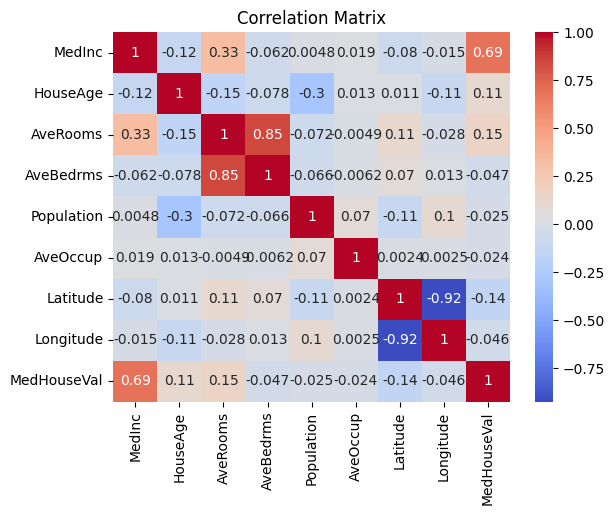

In [38]:
import seaborn as sns

sns.heatmap(df.corr(), annot= True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Split into Train and Test Sets

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state= 42)

print("Training Size: ", X_train.shape)
print("Testing Size: " , X_test.shape) 


Training Size:  (16512, 7)
Testing Size:  (4128, 7)


### Build And Train the model

In [40]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Trained Successfully")


Model Trained Successfully


### Evaluate the model

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))

print("MAE:", mean_absolute_error(y_test, y_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 1.0
MAE: 9.322530366106138e-14
RMSE: 1.628552110930325e-13


### Visualise and Interpret Results

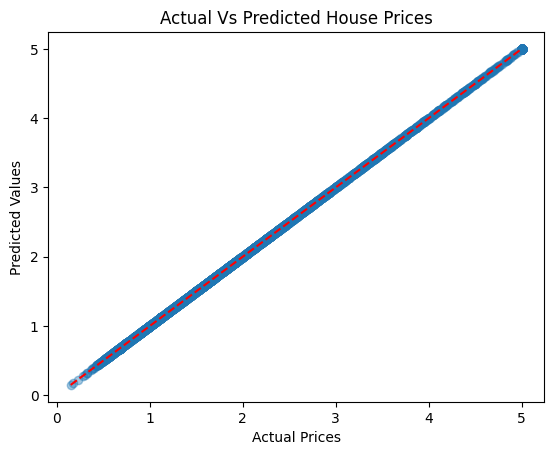

              Coefficient
MedInc       1.352478e-15
AveBedrms    1.284528e-13
Population  -1.240955e-16
AveOccup    -1.783243e-16
Latitude     1.608444e-15
Longitude    1.419423e-15
MedHouseVal  1.000000e+00


In [43]:
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Values")
plt.title("Actual Vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--') #perfect line
plt.show()

#See which feature matters most
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])

print(coeff_df)